In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [2]:
X, Y = 10,10
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t /2
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None, V=None, F0_init=0.1)#,
                # F_init=[0.1, -0.1, 0.1j, -0.1j])

In [3]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


In [4]:
print(H.lattice.pbc_x)

True


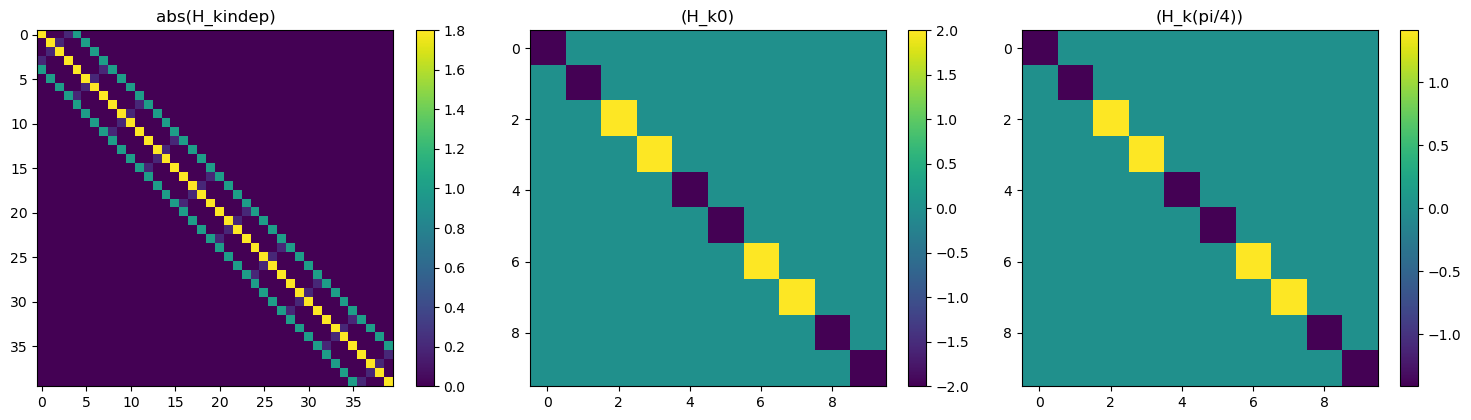

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im0 = axs[0].imshow(np.abs(H.build_H_kindep()))
axs[0].set_title("abs(H_kindep)")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(np.real(H.build_H_k0())[0:10, 0:10])
axs[1].set_title("(H_k0)")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.real(H.build_H_k(PI/4))[0:10, 0:10])
axs[2].set_title("(H_k(pi/4))")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


In [6]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.29351210027621744
Relative error: 2.935121002732823
Average old: (0.1+0j)
Average: (0.19172015903082906+0j)
F_xplus:
Absolute error: 0.15380339457330827
Relative error: 153803394573.30826
Average old: 0j
Average: (-0.05115595524867595+0j)
F_xmin:
Absolute error: 0.15380339457330855
Relative error: 153803394573.30856
Average old: 0j
Average: (-0.05115595524867604+0j)
F_yplus:
Absolute error: 0.22185690669519065
Relative error: 221856906695.19067
Average old: 0j
Average: (-0.0676358994284269-6.416742137638209e-17j)
F_ymin:
Absolute error: 0.22185690669519065
Relative error: 221856906695.19067
Average old: 0j
Average: (-0.0676358994284269+6.416742137638209e-17j)
Fuu_xplus:
Absolute error: 4.8793681768809335e-17
Relative error: 4.8793681768809334e-05
Average old: 0j
Average: (3.258102820136474e-18+0j)
Fuu_xmin:
Absolute error: 4.9206083214823455e-17
Relative error: 4.9206083214823456e-05
Average old: 0j
Average: (-1.0241494188206129e-17+0j)
Fuu_yplus:
Absolute error: 

In [7]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

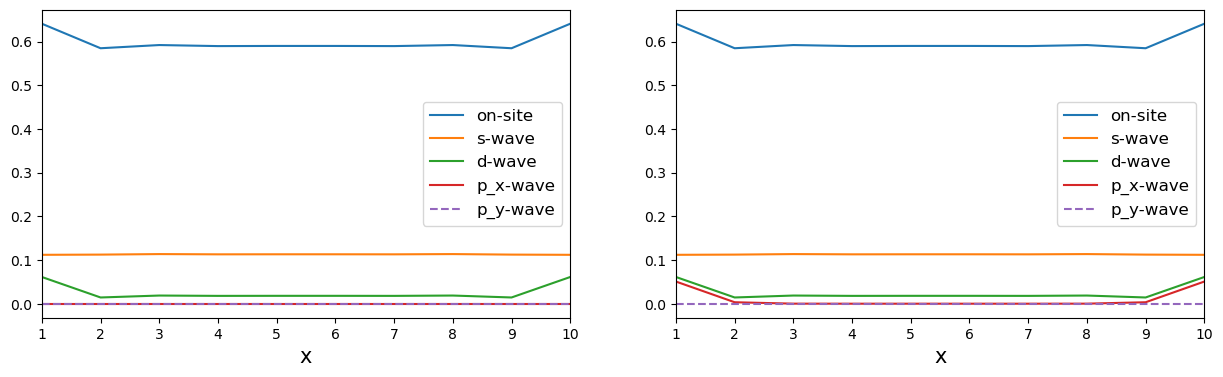

In [8]:
x = np.arange(1, X + 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(x, np.abs(F0), label="on-site")
axs[0].plot(x, np.abs(F_swave), label="s-wave")
axs[0].plot(x, np.abs(F_dwave), label="d-wave")
axs[0].plot(x, np.abs(F_px), label="p_x-wave")
axs[0].plot(x, np.abs(F_py), "--", label="p_y-wave")
axs[0].set_xlabel("x", fontsize=15)
axs[0].set_xlim(1, X)
axs[0].legend(fontsize=12, loc="best")

axs[1].plot(x, np.abs(F0), label="on-site")
axs[1].plot(x, np.abs(F_swave2), label="s-wave")
axs[1].plot(x, np.abs(F_dwave2), label="d-wave")
axs[1].plot(x, np.abs(F_px2), label="p_x-wave")
axs[1].plot(x, np.abs(F_py2), "--", label="p_y-wave")
axs[1].set_xlabel("x", fontsize=15)
axs[1].set_xlim(1, X)
axs[1].legend(fontsize=12, loc="best")

plt.show()

In [10]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.4

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [11]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=200, verbose=True, temperature=T)


F0:
Absolute error: 4.337129008144868e-16
Relative error: 0.00043371290081448686
Average old: 0j
Average: (4.3998564894954246e-17+0j)
F_xplus:
Absolute error: 0.041104858261404954
Relative error: 0.411048582609939
Average old: (0.09999999999999999+0j)
Average: (0.08767201145636497+0j)
F_xmin:
Absolute error: 0.04110485826140583
Relative error: 0.4110485826181688
Average old: (-0.09999999999999999+0j)
Average: (-0.08767201145636466+0j)
F_yplus:
Absolute error: 0.02699606117001783
Relative error: 0.2699606117001783
Average old: 0.1j
Average: (-5.588352312347498e-18+0.0915068212631174j)
F_ymin:
Absolute error: 0.02699606117001783
Relative error: 0.2699606117001783
Average old: -0.1j
Average: (-5.588352312347498e-18-0.0915068212631174j)
Fuu_xplus:
Absolute error: 2.603504614227607e-17
Relative error: 2.603504614227607e-05
Average old: 0j
Average: (-1.2175853864233465e-18+0j)
Fuu_xmin:
Absolute error: 2.909929880827876e-17
Relative error: 2.9099298808278763e-05
Average old: 0j
Average: (5.7

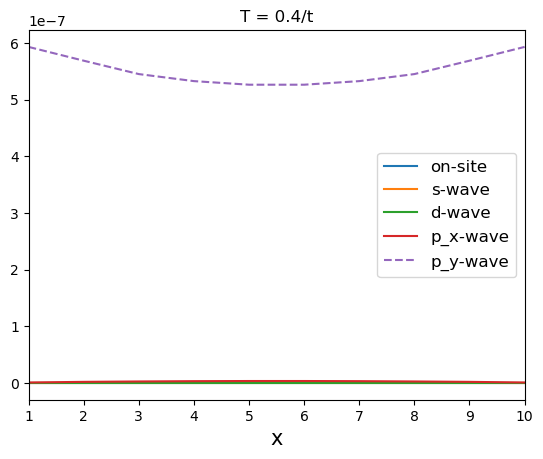

In [12]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

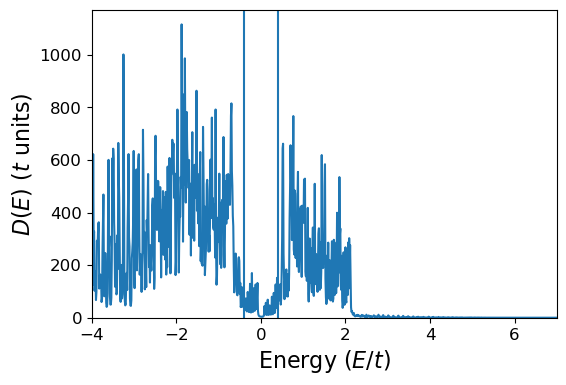

In [12]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.axvline(-0.2 * 2)
plt.axvline(+0.2 * 2)

# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [13]:
free1 = H.free
free2 = H.free_energy()

print(free1)
print(free2)

-127.9454734630715
51.896447155617075


In [10]:
X, Y = 10, 20
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 0.1 * t * np.ones(lattice.X)
T = 0.01

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1 , -0.1])

In [11]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.0350670973473647
Relative error: 35067097347.3647
Average old: 0j
Average: (0.010836119327615372+0j)
F_xplus:
Absolute error: 0.35382013729419376
Relative error: 3.538201372906555
Average old: (0.09999999999999999+0j)
Average: (0.2169773071218056+0j)
F_xmin:
Absolute error: 0.3538201372941936
Relative error: 3.5382013729065536
Average old: (0.09999999999999999+0j)
Average: (0.21697730712180557+0j)
F_yplus:
Absolute error: 0.3449467215220631
Relative error: 3.449467215255126
Average old: (-0.1+0j)
Average: (-0.2075748136941079+8.166210763160823e-18j)
F_ymin:
Absolute error: 0.3449467215220631
Relative error: 3.449467215255126
Average old: (-0.1+0j)
Average: (-0.2075748136941079-8.166210763160823e-18j)
Fuu_xplus:
Absolute error: 3.278090502108133e-17
Relative error: 3.278090502108133e-05
Average old: 0j
Average: (-4.589583601310682e-18+0j)
Fuu_xmin:
Absolute error: 4.417862705508784e-17
Relative error: 4.417862705508784e-05
Average old: 0j
Average: (7.76372990503119

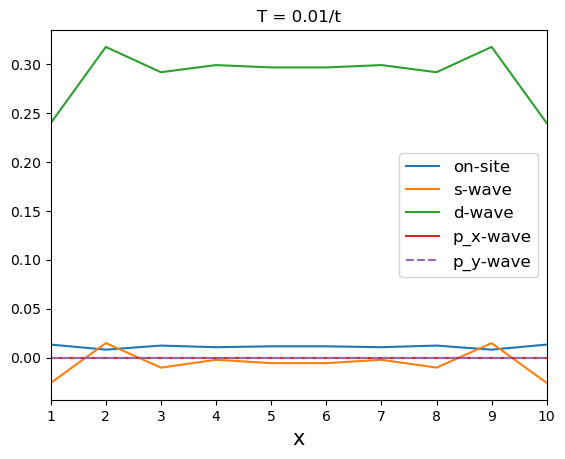

In [12]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

In [17]:
import numpy as np
temps = np.concatenate([
    np.arange(0.001, 0.020 + 1e-12, 0.001),
    np.arange(0.021, 0.040 + 1e-12, 0.0002),
    np.arange(0.041, 0.061 + 1e-12, 0.0002),
    np.arange(0.062, 0.080 + 1e-12, 0.0005),
    np.arange(0.081, 0.100 + 1e-12, 0.002)
])
len(temps)

264

In [22]:
X, Y = 25, 50
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 0.9 * t * np.ones(lattice.X)
T = 0.1

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t /2 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1+0.1, -0.1-0.1])

In [18]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, atol =1e-4,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.09795092384137324
Relative error: 97950923841.37323
Average old: 0j
Average: (0.013454743464616043+2.2371687835587304e-17j)
F_xplus:
Absolute error: 0.4039215769637653
Relative error: 4.03921576959726
Average old: (0.09999999999999999+0j)
Average: (0.1819809842790503-3.8900609260148384e-18j)
F_xmin:
Absolute error: 0.40392157696376496
Relative error: 4.039215769597257
Average old: (0.09999999999999999+0j)
Average: (0.1819809842790502-1.3529826673082383e-17j)
F_yplus:
Absolute error: 0.0916848653632356
Relative error: 91684865363.23561
Average old: 0j
Average: (-0.01622306163966027+8.21755857804972e-18j)
F_ymin:
Absolute error: 0.7689442467516842
Relative error: 3.8447212337776437
Average old: (-0.2+0j)
Average: (-0.3536673503442182-1.3919681379759307e-17j)
Fuu_xplus:
Absolute error: 9.445872620229822e-17
Relative error: 9.44587262022982e-05
Average old: 0j
Average: (-1.4771829208286692e-22+1.4641877278438024e-17j)
Fuu_xmin:
Absolute error: 1.0095685945545078e-16
R

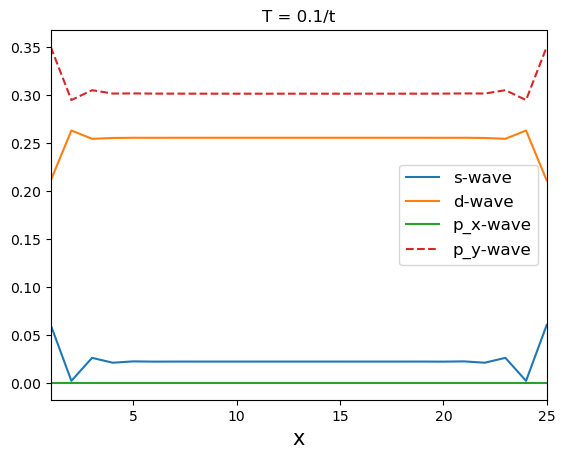

In [19]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
# plt.plot(x, np.abs(F0), label="on-site")
plt.plot(x, np.abs(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.real(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")